# Mitigation d'erreurs sur MonarQ

Ce notebook illustre les techniques de mitigation disponibles dans `qiskit-calculquebec` :

| Technique | Classe | Erreur ciblée |
|---|---|---|
| **REM matrix** | `ReadoutMitigation(method='matrix')` | Erreurs de lecture (≤ ~12 qubits) |
| **REM M3** | `ReadoutMitigation(method='m3')` | Erreurs de lecture (jusqu'à 24 qubits) |
| **ZNE** | `ZNEMitigation` | Bruit de portes |
| **ZNE + REM** | `ZNEMitigation.run(rem=...)` | Combinaison |
| **ZNE Observable** | `ZNEMitigation.run(observable=...)` | Observable Pauli quelconque |
| **DDD** | `DDDMitigation` | Bruit de déphasing (idle) |
| **DDD + REM** | `DDDMitigation.run(rem=...)` | Combinaison |
| **Pauli Twirling** | `PauliTwirlingMitigation` | Bruit cohérent sur portes 2-qubits |
| **PT + ZNE** | `PauliTwirlingMitigation.run_with_zne()` | Combinaison |

## 1. Imports et connexion

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_calculquebec.API.client import CalculQuebecClient
from qiskit_calculquebec.backends import MonarQBackend

# ── Mitigation ──────────────────────────────────────────────────────────
from qiskit_calculquebec.mitigation import (
    ReadoutMitigation,
    ZNEMitigation,
    DDDMitigation,
    PauliTwirlingMitigation,
)

In [2]:
load_dotenv()
my_client = CalculQuebecClient(
    os.getenv("HOST"),
    os.getenv("USER"),
    os.getenv("ACCESS_TOKEN"),
    project_id=os.getenv("PROJECT_ID"),
)
backend = MonarQBackend("yukon", my_client)
shots   = 1000

---
## 2. Circuit de test — GHZ 3 qubits

L'état GHZ idéal donne P(|000⟩) = P(|111⟩) = 0.5 et tous les autres états à 0.
On l'utilise pour mesurer l'impact de chaque technique.

In [3]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure_all()

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
transpiled_qc = pm.run(qc)

# Qubits physiques après transpilation
if transpiled_qc.layout and transpiled_qc.layout.final_layout:
    physical_qubits = [
        transpiled_qc.layout.final_layout[q]
        for q in transpiled_qc.qubits
    ]
else:
    physical_qubits = list(range(3))

print(f"Qubits physiques : {physical_qubits}")

# Exécution brute (référence)
sampler    = Sampler(mode=backend)
job        = sampler.run([transpiled_qc], shots=shots)
counts_raw = job.result()[0].data.meas.get_counts()
print(f"Counts bruts : {counts_raw}")

Qubits physiques : [0, 1, 2]
Counts bruts : {'000': 449, '001': 34, '010': 16, '011': 56, '100': 54, '101': 55, '110': 42, '111': 294}


---
## 3. REM — Readout Error Mitigation

Corrige les erreurs de lecture en utilisant les fidélités P(0|0) et P(1|1)
lues depuis le benchmark Anyon (aucun circuit de calibration soumis au hardware).

### 3a. Méthode matrix (mitiq) — exacte, ≤ ~12 qubits

In [4]:
rem_matrix = ReadoutMitigation(backend, method='matrix')
rem_matrix.cals_from_system()

# Afficher les fidélités
print("Fidélités de lecture (method='matrix') :")
for q, info in zip(range(backend.target.num_qubits), rem_matrix.readout_fidelity()):
    if info is not None:
        print(f"  qubit {q:2d} : P(0|0)={info['p00']:.4f}  P(1|1)={info['p11']:.4f}  moy={info['mean']:.4f}")

# Correction
counts_rem_matrix = rem_matrix.apply_correction(counts_raw, qubits=physical_qubits)
print(f"\nCounts bruts  : {counts_raw}")
print(f"Counts mitigés (matrix) : {counts_rem_matrix}")

#plot_histogram([counts_raw,counts_rem_matrix], legend=["raw","mitig"])

Fidélités de lecture (method='matrix') :
  qubit  0 : P(0|0)=0.9610  P(1|1)=0.9100  moy=0.9355
  qubit  1 : P(0|0)=0.9730  P(1|1)=0.8430  moy=0.9080
  qubit  2 : P(0|0)=0.9600  P(1|1)=0.9430  moy=0.9515
  qubit  3 : P(0|0)=0.9800  P(1|1)=0.8900  moy=0.9350
  qubit  4 : P(0|0)=0.9470  P(1|1)=0.8820  moy=0.9145
  qubit  5 : P(0|0)=0.9630  P(1|1)=0.9230  moy=0.9430

Counts bruts  : {'000': 449, '001': 34, '010': 16, '011': 56, '100': 54, '101': 55, '110': 42, '111': 294}
Counts mitigés (matrix) : {'111': 373, '000': 532, '100': 39, '011': 44, '110': 9, '001': 3}


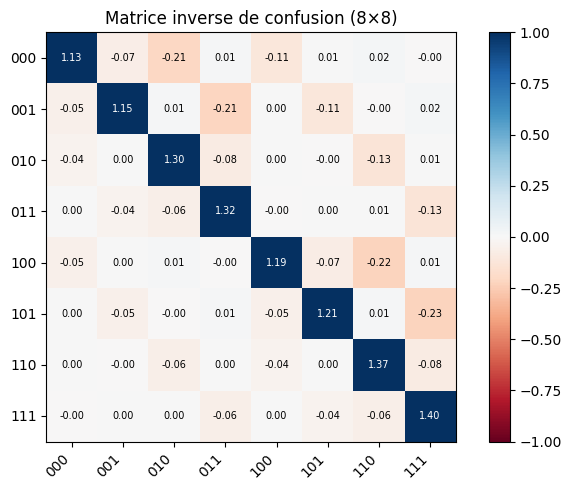

In [5]:
# Visualiser la matrice inverse de confusion
import matplotlib.pyplot as plt

inv_A = rem_matrix.get_inv_confusion_matrix(physical_qubits)
n = len(physical_qubits)
labels = [format(i, f"0{n}b") for i in range(2**n)]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(inv_A, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(2**n)); ax.set_yticks(range(2**n))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_title(f"Matrice inverse de confusion ({2**n}×{2**n})")
for i in range(2**n):
    for j in range(2**n):
        ax.text(j, i, f"{inv_A[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="black" if abs(inv_A[i,j]) < 0.5 else "white")
plt.colorbar(im)
plt.tight_layout()
plt.show()

### 3b. Méthode M3 (mthree) — scalable, recommandée pour MonarQ

In [10]:
rem_m3 = ReadoutMitigation(backend, method='m3')
rem_m3.cals_from_system()

# Correction M3
quasi = rem_m3.apply_correction(counts_raw, qubits=physical_qubits)

# Convertir quasi-probas → counts
counts_rem_m3 = {
    k: int(round(v * shots))
    for k, v in quasi.nearest_probability_distribution().items()
    if round(v * shots) > 0
}

print(f"Counts bruts    : {counts_raw}")
print(f"Counts M3       : {counts_rem_m3}")

# Détails du solveur
quasi_d, info = rem_m3.apply_correction(
    counts_raw, qubits=physical_qubits, details=True
)
print(f"\nSolveur utilisé   : {info['method']}")
print(f"Temps (s)         : {info['time']:.4f}")
print(f"Bitstrings distincts : {info['dimension']}")

Counts bruts    : {'000': 449, '001': 34, '010': 16, '011': 56, '100': 54, '101': 55, '110': 42, '111': 294}
Counts M3       : {'001': 6, '110': 14, '100': 31, '011': 50, '111': 403, '000': 496}

Solveur utilisé   : direct
Temps (s)         : 0.0001
Bitstrings distincts : 8


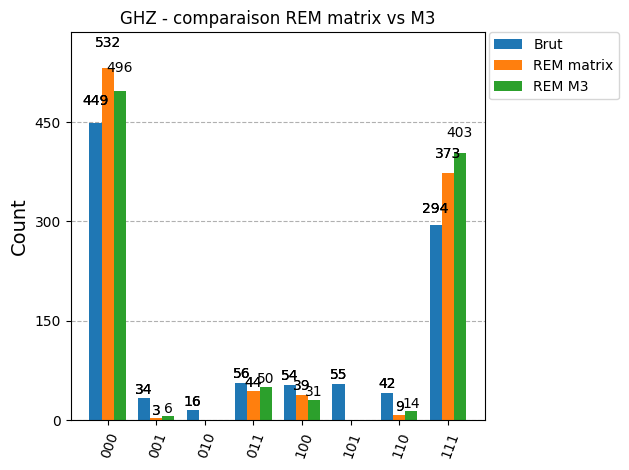

In [11]:
plot_histogram(
    [counts_raw, counts_rem_matrix, counts_rem_m3],
    legend=["Brut", "REM matrix", "REM M3"],
    title="GHZ - comparaison REM matrix vs M3",
)

---
## 4. ZNE — Zero-Noise Extrapolation

Exécute le circuit à plusieurs niveaux de bruit amplifiés et extrapole
la valeur à bruit nul. Retourne `P(|000⟩)`.

In [12]:
# Circuit ZNE — même GHZ 3 qubits
qc_zne = QuantumCircuit(3)
qc_zne.h(0)
qc_zne.cx(0, 1)
qc_zne.cx(1, 2)
qc_zne.measure_all()

zne_mit = ZNEMitigation(backend, scale_factors=[1.0, 1.5, 2.0, 2.5, 3.0])

raw_zne = zne_mit.run_unmitigated(qc_zne)
mit_zne = zne_mit.run(qc_zne)

print(f"Brut (scale=1) : {raw_zne:.4f}")
print(f"ZNE mitigé     : {mit_zne:.4f}")
print(f"Idéal          : 0.5000")

/opt/miniconda3/envs/qiskit-cq-env/lib/python3.12/site-packages/mitiq/zne/inference.py:88: UserWarning: The input circuit is very short. This may reduce the accuracy of noise scaling.
  warnings.warn(


Brut (scale=1) : 0.4502
ZNE mitigé     : 0.4488
Idéal          : 0.5000


In [13]:
# Comparer plusieurs configurations ZNE
from mitiq.zne.inference import LinearFactory, RichardsonFactory
from mitiq.zne.scaling import fold_global

configs = [
    ("Richardson [1,2,3] + fold_random",   RichardsonFactory([1.0, 2.0, 3.0]), None),
    ("Richardson [1,3,5] + fold_random",   RichardsonFactory([1.0, 3.0, 5.0]), None),
    ("Linear [1,1.5,2,2.5,3] + fold_random", LinearFactory([1.0, 1.5, 2.0, 2.5, 3.0]), None),
    ("Richardson [1,2,3] + fold_global",   RichardsonFactory([1.0, 2.0, 3.0]), fold_global),
    ("Linear [1,2,3] + fold_global",       LinearFactory([1.0, 2.0, 3.0]),     fold_global),
]

print(f"{'Config':50s}  {'Mitigé':>8}  {'Erreur':>8}")
print("-" * 70)
for label, factory, scale_noise in configs:
    zne_cfg = ZNEMitigation(backend, factory=factory, scale_noise=scale_noise)
    val = zne_cfg.run(qc_zne)
    print(f"{label:50s}  {val:8.4f}  {abs(0.5 - val):8.4f}")

Config                                                Mitigé    Erreur
----------------------------------------------------------------------


/opt/miniconda3/envs/qiskit-cq-env/lib/python3.12/site-packages/mitiq/zne/inference.py:88: UserWarning: The input circuit is very short. This may reduce the accuracy of noise scaling.
  warnings.warn(


Richardson [1,2,3] + fold_random                      0.4443    0.0557


/opt/miniconda3/envs/qiskit-cq-env/lib/python3.12/site-packages/mitiq/zne/inference.py:88: UserWarning: The input circuit is very short. This may reduce the accuracy of noise scaling.
  warnings.warn(


Richardson [1,3,5] + fold_random                      0.5063    0.0063


...

Linear [1,1.5,2,2.5,3] + fold_random                  0.4400    0.0600


/opt/miniconda3/envs/qiskit-cq-env/lib/python3.12/site-packages/mitiq/zne/inference.py:88: UserWarning: The input circuit is very short. This may reduce the accuracy of noise scaling.
  warnings.warn(


Richardson [1,2,3] + fold_global                      0.6563    0.1563


/opt/miniconda3/envs/qiskit-cq-env/lib/python3.12/site-packages/mitiq/zne/inference.py:88: UserWarning: The input circuit is very short. This may reduce the accuracy of noise scaling.
  warnings.warn(


Linear [1,2,3] + fold_global                          0.4092    0.0908


### ZNE + REM combinés

In [14]:
# Les qubits physiques doivent correspondre à optimization_level=0
# (même niveau que l'executor ZNE utilise en interne)
pm_zne = generate_preset_pass_manager(optimization_level=0, backend=backend)
t_zne = pm_zne.run(qc_zne)
if t_zne.layout and t_zne.layout.final_layout:
    phys_zne = [t_zne.layout.final_layout[q] for q in t_zne.qubits]
else:
    phys_zne = list(range(qc_zne.num_qubits))

# Réutilise rem_m3 déjà calibré (section 3b)
mit_zne_rem = zne_mit.run(qc_zne, rem=rem_m3, qubits=phys_zne)

print(f"Brut (scale=1)  : {raw_zne:.4f}")
print(f"ZNE seul        : {mit_zne:.4f}")
print(f"ZNE + REM M3    : {mit_zne_rem:.4f}")
print(f"Idéal           : 0.5000")

/opt/miniconda3/envs/qiskit-cq-env/lib/python3.12/site-packages/mitiq/zne/inference.py:88: UserWarning: The input circuit is very short. This may reduce the accuracy of noise scaling.
  warnings.warn(


Brut (scale=1)  : 0.4502
ZNE seul        : 0.4488
ZNE + REM M3    : 0.4791
Idéal           : 0.5000


### ZNE avec Observable Pauli (⟨Z₀Z₁⟩)

Par défaut ZNE mesure P(|0…0⟩). En passant un ``Observable`` mitiq,
l'executor retourne des bitstrings bruts et mitiq calcule l'espérance.

Pour l'état GHZ idéal `(|000⟩ + |111⟩)/√2` :
- ⟨Z₀Z₁⟩ = 1 (qubits 0 et 1 toujours corrélés)
- ⟨Z₀⟩ = 0 (superposition égale)

In [15]:
from mitiq import Observable, PauliString

# ⟨Z₀Z₁⟩ = 1 pour l'état GHZ idéal
obs_zz = Observable(PauliString("ZZ", support=[0, 1]))

raw_obs = zne_mit.run_unmitigated(qc_zne, observable=obs_zz)
mit_obs = zne_mit.run(qc_zne, observable=obs_zz)

print(f"Brut   ⟨Z₀Z₁⟩ : {raw_obs:.4f}")
print(f"ZNE    ⟨Z₀Z₁⟩ : {mit_obs:.4f}")
print(f"Idéal  ⟨Z₀Z₁⟩ : 1.0000")

/opt/miniconda3/envs/qiskit-cq-env/lib/python3.12/site-packages/mitiq/zne/inference.py:88: UserWarning: The input circuit is very short. This may reduce the accuracy of noise scaling.
  warnings.warn(


Brut   ⟨Z₀Z₁⟩ : 0.6875
ZNE    ⟨Z₀Z₁⟩ : 0.6867
Idéal  ⟨Z₀Z₁⟩ : 1.0000


---
## 5. DDD — Digital Dynamical Decoupling

Insère des séquences de portes (XX, YY, XYXY) dans les fenêtres
inactives du circuit pour réduire le déphasing.

In [ ]:
# Circuit avec fenêtres idle (GHZ + idle + GHZ inverse)
def make_ghz_idle(depth: int, n: int = 2) -> QuantumCircuit:
    qc = QuantumCircuit(n, n)
    qc.h(0)
    qc.cx(0, 1)
    for _ in range(depth):
        qc.id(0); qc.id(1)
    qc.cx(0, 1)
    qc.h(0)
    qc.measure(range(n), range(n))
    return qc

DEPTHS = [4, 10, 30, 50]
results_ddd = {d: {} for d in DEPTHS}

for depth in DEPTHS:
    circuit = make_ghz_idle(depth)
    print(f"\n── depth = {depth} ──────────────")
    for rule in ["xx", "yy", "xyxy"]:
        ddd = DDDMitigation(backend, rule=rule, num_trials=3)
        raw = ddd.run_unmitigated(circuit)
        mit = ddd.run(circuit)
        results_ddd[depth][rule] = mit
        print(f"  rule={rule:<5} : brut={raw:.4f}  DDD={mit:.4f}  err={abs(1.0-mit):.4f}")

### DDD + REM combinés

In [ ]:
# Initialiser REM une seule fois
rem = ReadoutMitigation(backend, method='m3')
rem.cals_from_system()

# Récupérer les qubits physiques du circuit idle
circuit_idle = make_ghz_idle(10)
pm_ref = generate_preset_pass_manager(optimization_level=0, backend=backend)
t = pm_ref.run(circuit_idle)
if t.layout and t.layout.final_layout:
    phys = [t.layout.final_layout[q] for q in t.qubits]
else:
    phys = list(range(circuit_idle.num_qubits))

ddd_rem = DDDMitigation(backend, rule='xyxy', num_trials=3)

val_raw      = ddd_rem.run_unmitigated(circuit_idle)
val_ddd      = ddd_rem.run(circuit_idle)
val_ddd_rem  = ddd_rem.run(circuit_idle, rem=rem, qubits=phys)

print(f"Brut          : {val_raw:.4f}   (err={abs(1.0-val_raw):.4f})")
print(f"DDD xyxy      : {val_ddd:.4f}   (err={abs(1.0-val_ddd):.4f})")
print(f"DDD + REM M3  : {val_ddd_rem:.4f}   (err={abs(1.0-val_ddd_rem):.4f})")

---
## 6. Pauli Twirling

Génère des variantes du circuit avec des Pauli aléatoires autour des portes
2-qubits (CNOT, CZ) pour convertir le bruit cohérent en dépolarisation.

In [ ]:
qc_pt = QuantumCircuit(4)
qc_pt.h(0)
qc_pt.cx(0, 1)
qc_pt.cz(1, 2)
qc_pt.cx(2, 3)
qc_pt.measure_all()

pt = PauliTwirlingMitigation(backend, num_variants=3)

raw_pt = pt.run_unmitigated(qc_pt)
mit_pt = pt.run(qc_pt)

print(f"Brut          : {raw_pt:.4f}")
print(f"PT (N=3)     : {mit_pt:.4f}")

# Voir la variance des variantes individuelles
variants_vals = pt.run_variants(qc_pt)
print(f"Variantes     : {[f'{v:.4f}' for v in variants_vals]}")
print(f"Std           : {np.std(variants_vals):.4f}")

### PT + ZNE combinés

In [ ]:
pt_zne = PauliTwirlingMitigation(backend, num_variants=10)

raw        = pt_zne.run_unmitigated(qc_pt)
pt_only    = pt_zne.run(qc_pt)
pt_zne_val = pt_zne.run_with_zne(qc_pt)

print(f"Brut         : {raw:.4f}")
print(f"PT seul      : {pt_only:.4f}")
print(f"PT + ZNE     : {pt_zne_val:.4f}")

# Avec factory personnalisée
from mitiq.zne.inference import RichardsonFactory
val_rich = pt_zne.run_with_zne(
    qc_pt,
    factory=RichardsonFactory([1.0, 2.0, 3.0]),
)
print(f"PT + ZNE (Richardson [1,2,3]) : {val_rich:.4f}")

---
## 7. Récapitulatif

Tableau comparatif de toutes les techniques sur le circuit GHZ 3 qubits.

In [ ]:
# Résumé : P(|000⟩) pour le circuit GHZ 3 qubits (idéal = 0.5)
ideal = 0.5

def p000_from_counts(counts, n_shots=shots):
    return counts.get("000", 0) / n_shots

raw_p        = p000_from_counts(counts_raw)
rem_matrix_p = p000_from_counts(counts_rem_matrix)
rem_m3_p     = p000_from_counts(counts_rem_m3)

print(f"{'Technique':<30}  {'P(|000⟩)':>10}  {'Erreur':>8}")
print("-" * 52)
print(f"{'Idéal':<30}  {ideal:>10.4f}  {'—':>8}")
print(f"{'Brut':<30}  {raw_p:>10.4f}  {abs(ideal-raw_p):>8.4f}")
print(f"{'REM matrix':<30}  {rem_matrix_p:>10.4f}  {abs(ideal-rem_matrix_p):>8.4f}")
print(f"{'REM M3':<30}  {rem_m3_p:>10.4f}  {abs(ideal-rem_m3_p):>8.4f}")
print(f"{'ZNE':<30}  {mit_zne:>10.4f}  {abs(ideal-mit_zne):>8.4f}")
print(f"{'ZNE + REM M3':<30}  {mit_zne_rem:>10.4f}  {abs(ideal-mit_zne_rem):>8.4f}")